# Negative Hypergeometric Distribution

`NegativeHypergeometric(r, N0, N1)` describes the following experiment. A jar holds `N0` zeros and `N1` ones. Draw them out one at a time, *without* replacement, and stop as soon as you have pulled `r` zeros. The distribution is of **how many ones you drew along the way**.

For instance: 7 blue marbles and 5 red ones, drawing until the 3rd blue appears. How many reds did you collect? The answer is somewhere from 0 (the first three draws were all blue) up to 5 (every red came out before the third blue).

It is the without-replacement cousin of the `Pascal` distribution, and the "keep drawing until" version of `Hypergeometric` -- we compare it to both further down.

In [1]:
from symbulate import *

## Draw a value from a negative hypergeometric distribution

In [2]:
NegativeHypergeometric(r=3, N0=7, N1=5).draw()

1

## Theoretical mean, variance, and standard deviation

The mean has a tidy form: `r * N1 / (N0 + 1)`. Reading it as a rate helps -- each zero you wait for buys you, on average, `N1 / (N0 + 1)` ones.

In [3]:
X = NegativeHypergeometric(r=3, N0=7, N1=5)
X.mean(), X.var(), X.sd()

(np.float64(1.875),
 np.float64(1.6927083333333335),
 np.float64(1.301041249666333))

In [4]:
3 * 5 / (7 + 1)

1.875

## Assign and simulate a random variable

In [5]:
N = RV(NegativeHypergeometric(r=3, N0=7, N1=5))
sims = N.sim(10000)
sims

Simulating... [██████████████████░░░░░░░░░░░░] 6140/10000 (61%)

Simulating... [██████████████████░░░░░░░░░░░░] 6200/10000 (62%)

Simulating... [██████████████████░░░░░░░░░░░░] 6300/10000 (63%)

Simulating... [███████████████████░░░░░░░░░░░] 6400/10000 (64%)

Simulating... [███████████████████░░░░░░░░░░░] 6500/10000 (65%)

...

Simulating... [█████████████████████████████░] 9800/10000 (98%)

Simulating... [█████████████████████████████░] 9900/10000 (99%)

Simulating... [██████████████████████████████] 10000/10000 (100%)

Simulating... [██████████████████████████████] 10000/10000 (100%)

0,1
1,1
2,2
3,0
4,0
5,0
6,1
7,2
8,2
...,...
9999,2


Because the possible values are just 0 through 5, a frequency table is an easy way to see the whole distribution at once.

In [6]:
sims.tabulate()

0,1614
1,2665
2,2594
3,1962
4,923
5,242
Total,10000


Those counts, divided by 10000, should sit close to the theoretical probabilities.

In [7]:
[round(float(X.pmf(k)), 4) for k in range(6)]

[0.1591, 0.2652, 0.2652, 0.1894, 0.0947, 0.0265]

## Plot the pmf

A dot at each possible value, joined by a dashed line -- dashed as a reminder that nothing exists between the whole numbers.

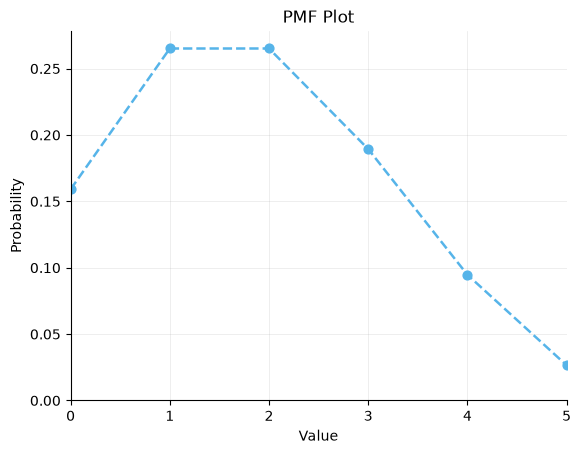

In [8]:
NegativeHypergeometric(r=3, N0=7, N1=5).plot()

## Plot the CDF

For a discrete distribution this is a step function, jumping at each possible value.

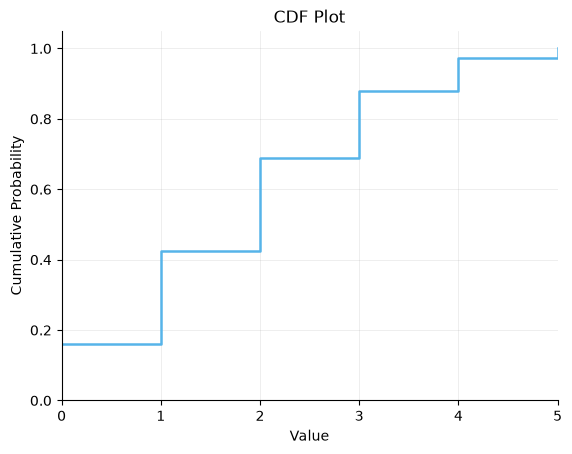

In [9]:
NegativeHypergeometric(r=3, N0=7, N1=5).plot(cdf=True)

## Simulated values against the theoretical pmf

The simulated results are drawn as impulses, with the theoretical pmf on top.

Currently Showing: Impulse Plot (Default)
Alternative Plots: Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


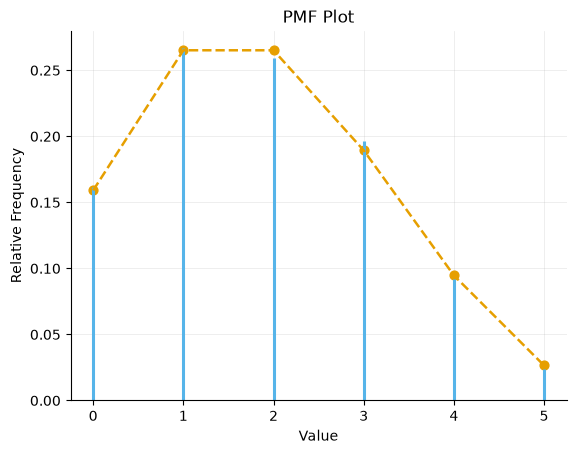

In [10]:
sims.plot()
NegativeHypergeometric(r=3, N0=7, N1=5).plot()

## Waiting for more zeros collects more ones

Raising `r` means drawing for longer, so more ones come out along the way. At `r = 1` the most likely outcome is no ones at all; by `r = 7` -- waiting for every single zero -- you are most likely to have collected all 5 ones.

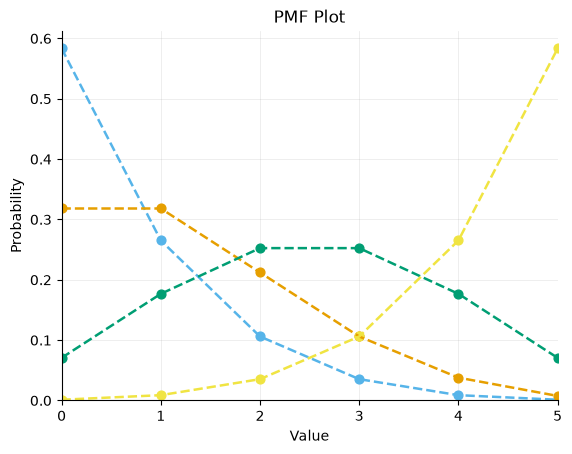

In [11]:
for r in [1, 2, 4, 7]:
    NegativeHypergeometric(r=r, N0=7, N1=5).plot()

In [12]:
[float(NegativeHypergeometric(r=r, N0=7, N1=5).mean()) for r in [1, 2, 4, 7]]

[0.625, 1.25, 2.5, 4.375]

## Comparison: the same jar, a different question

`Hypergeometric` fixes the **number of draws** and asks how many ones turn up. `NegativeHypergeometric` fixes the **number of zeros to collect** and asks the same thing, letting the number of draws vary.

With 3 draws the hypergeometric can never exceed 3 ones, so its curve stops there. The negative hypergeometric keeps drawing until 3 zeros appear, which may take many more draws, so it can reach all the way to 5.

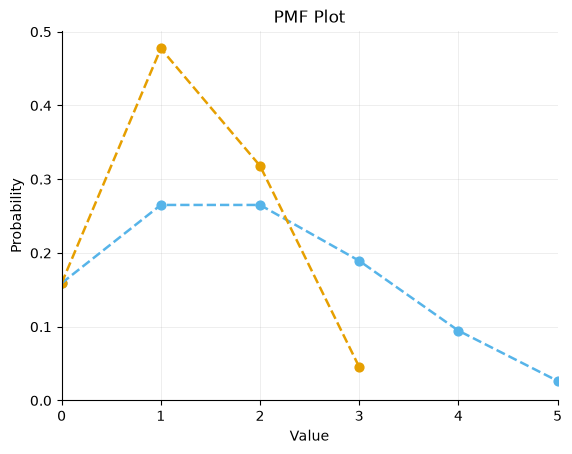

In [13]:
NegativeHypergeometric(r=3, N0=7, N1=5).plot()
Hypergeometric(n=3, N0=7, N1=5).plot()

In [14]:
float(NegativeHypergeometric(r=3, N0=7, N1=5).mean()), float(Hypergeometric(n=3, N0=7, N1=5).mean())

(1.875, 1.25)

## Two things to watch out for

**`r` counts zeros here, not ones.** In `NegativeBinomial` and `Pascal` the stopping count `r` is a number of *successes*. In this distribution `r` is the number of *zeros* to wait for, and the ones are what gets counted up.

**`r` cannot be larger than `N0`.** You cannot wait for 8 zeros out of a jar holding only 7 -- the experiment would never end. Asking for that raises a clear error rather than quietly returning a missing value.

In [15]:
# Waiting for every zero in the jar is fine; asking for one more is not.
float(NegativeHypergeometric(r=7, N0=7, N1=5).mean())

4.375